# Урок 12.2. Значения Шепли и SHAP

**Интерактивная версия:** `lessons/lesson_12_2/web/index.html`

1. Значения Шепли по определению: все коалиции для модели с тремя признаками.
2. Сверка нашего перебора с `shap.TreeExplainer` на модели scikit-learn.
3. «Путевой» и «интервенционный» способы при коррелированных признаках.
4. Сводный график и график зависимости в `shap`.

In [1]:
import itertools
import math
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
from sklearn.ensemble import GradientBoostingRegressor
from gbcourse import datasets, GBRegressor
from gbcourse.explain import expected_value, shapley_values, sklearn_tree_to_nodes

X, y = datasets.friedman1(n=600, noise=1.0, seed=180, n_features=7)

## 1. По определению

In [2]:
Xs = X[:, [0, 1, 3]]
model = GBRegressor(n_estimators=50, max_depth=2, learning_rate=0.2).fit(Xs, y)
x = Xs[0]
F0 = float(np.ravel(model.init_)[0])
v = lambda S: F0 + sum(model.learning_rate * expected_value(st[0], x, set(S)) for st in model.trees_)
print("ценности коалиций:")
for r in range(4):
    for S in itertools.combinations(range(3), r):
        print(f"  v({set(S) or '∅'}) = {v(S):.4f}")
d = 3
phi = np.zeros(d)
for j in range(d):
    others = [k for k in range(d) if k != j]
    for r in range(d):
        for S in itertools.combinations(others, r):
            phi[j] += math.factorial(len(S)) * math.factorial(d - len(S) - 1) / math.factorial(d) * (v(S + (j,)) - v(S))
print("по определению:", np.round(phi, 6), "| shapley_values:", np.round(shapley_values(model, x)[1], 6))

ценности коалиций:
  v(∅) = 14.4494
  v({0}) = 15.9465
  v({1}) = 16.3857
  v({2}) = 15.7497
  v({0, 1}) = 18.0886
  v({0, 2}) = 17.0423
  v({1, 2}) = 17.8012
  v({0, 1, 2}) = 19.2995
по определению: [1.497743 2.096754 1.255598] | shapley_values: [1.497743 2.096754 1.255598]


## 2. Сверка с shap на модели scikit-learn

`sklearn_tree_to_nodes` переводит деревья scikit-learn в формат `gbcourse`, и мы считаем значения Шепли перебором.

In [3]:
sk = GradientBoostingRegressor(n_estimators=30, max_depth=3, learning_rate=0.1, random_state=0).fit(X, y)
explainer = shap.TreeExplainer(sk)
sv = explainer.shap_values(X[:10])


trees = [sklearn_tree_to_nodes(est[0], learning_rate=sk.learning_rate) for est in sk.estimators_]
ours = np.array([sum(shapley_values(t, X[i])[1] for t in trees) for i in range(10)])  # аддитивность: сумма по деревьям
print("наибольшее расхождение с shap:", np.abs(ours - sv).max())

наибольшее расхождение с shap: 2.220446049250313e-15


## 3. Путевой и интервенционный способы при коррелированных признаках

Добавим почти точную копию x0. Путевой способ делит вклад между x0 и копией по тому, как их использовали деревья;
интервенционный меняет каждый признак независимо от другого.

In [4]:
rng = np.random.default_rng(0)
Xc = np.c_[X, X[:, 0] + rng.normal(0, 0.01, len(y))]
# Модель scikit-learn: shap 0.52 не поддерживает интервенционный режим для моделей XGBoost 3.x
skc = GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=0).fit(Xc, y)
path = shap.TreeExplainer(skc, feature_perturbation="tree_path_dependent").shap_values(Xc[:200])
interv = shap.TreeExplainer(skc, data=shap.maskers.Independent(Xc[200:400], max_samples=200),  # весь фон, без подвыборки
                        feature_perturbation="interventional").shap_values(Xc[:200])
cols = [f"x{j}" for j in range(7)] + ["копия x0"]
pd.DataFrame({"путевой: средний |φ|": np.abs(path).mean(0), "интервенционный: средний |φ|": np.abs(interv).mean(0)}, index=cols).round(3)

,путевой: средний |φ|,интервенционный: средний |φ|
x0,0.811,0.821
x1,1.807,1.782
x2,1.101,1.094
x3,2.336,2.278
x4,1.178,1.178
x5,0.121,0.120
x6,0.081,0.080
копия x0,0.691,0.719


Здесь способы почти совпали; в обоих вклад x0 поделён между x0 и копией (0.81 + 0.69).

## 4. Графики shap

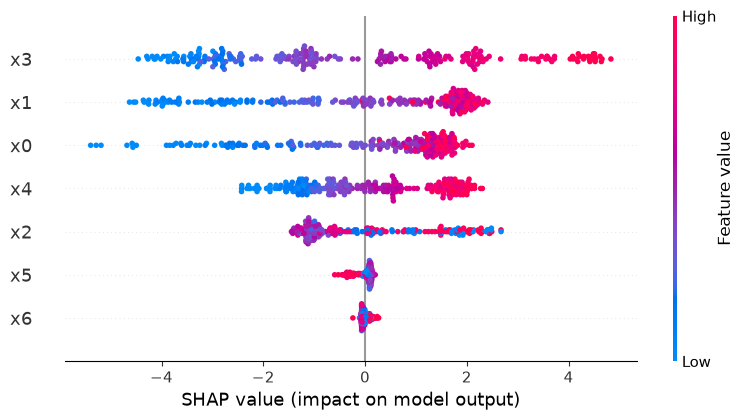

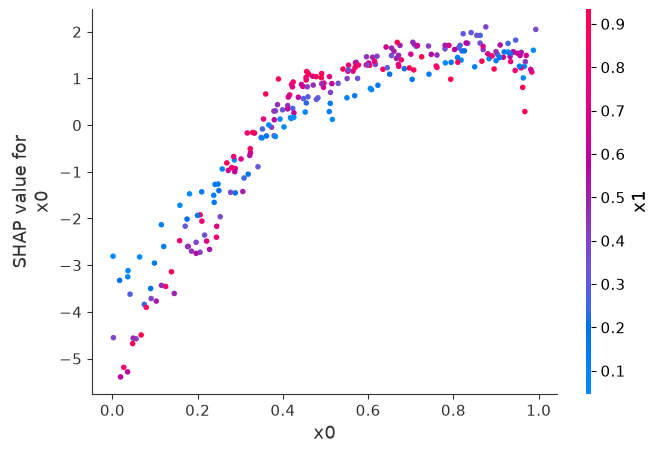

In [5]:
xm7 = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1).fit(X, y)
sv7 = shap.TreeExplainer(xm7).shap_values(X[:250])
shap.summary_plot(sv7, X[:250], feature_names=[f"x{j}" for j in range(7)], show=False)
plt.show()
shap.dependence_plot(0, sv7, X[:250], feature_names=[f"x{j}" for j in range(7)], interaction_index=1, show=False)
plt.show()

## Упражнения

1. Модель F(x) = x₀·x₁ на независимых U(0, 1). Вычислите φ₀ и φ₁ для объекта (1, 1) по определению.
2. Проверьте аксиому нулевого игрока: добавьте признак-константу и убедитесь, что его вклад — ноль.

Решения: `python lessons/lesson_12_2/exercises/solutions.py`.